In [159]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from tqdm import tqdm
import pandas as pd
import time
from numba import njit
from scipy.integrate import quad
import math
import pandas as pd

In [17]:
k_a = 1 #1.380649e-34 # Constante de Boltzman
J = 1.0 # Constante de acoplamiento

In [5]:
def init(N):
  return np.random.choice([-1, 1], size=(N, N))

Temperatura crítica: $\sinh(2J/(k_B T_c)) = 1$

In [9]:
critic_temperature = (2* J) / (k_a * math.asinh(1))
critic_temperature

2.269185314213022

In [10]:
@njit
def delta_energia(i, j, P0, N, h):
  x0 = P0.copy()
  i = i % N
  j = j % N
  ip = (i + 1) % N
  im = (i - 1) % N
  jp = (j + 1) % N
  jm = (j - 1) % N

  delta = (2 * J * x0[i, j] * (x0[ip, j]
          + x0[im, j] + x0[i, jp]
          + x0[i, jm])) + 2 * h * x0[i, j]

  return delta

In [78]:
@njit
def energy_per_site(p0, J, N, h):
  energy = 0
  for i in range(N):
      for j in range(N):
          ip = (i + 1) % N
          jp = (j + 1) % N
          c = p0[i, j] * (p0[ip, j] + p0[i, jp])
          energy += -J * c + h * p0[i, j]
  energy_per_site = energy / N**2
  return energy_per_site

@njit
def magentization_per_spin(p0, N):
    return np.sum(p0) / (N ** 2)


In [138]:
@njit
def metropolis_one_step(x0, beta, N, h):
  """Realiza un paso de Metropolis en el sistema"""
  x0_old = x0.copy()
  i, j=np.random.randint(0, N, size=2)




  delta_E=delta_energia(i, j, x0, N, h)


  u=np.random.rand()

  if delta_E<= 0 or  np.exp(-beta*delta_E) >= u:
      x0[i, j]*=-1




  return x0

@njit
def metropolis_total(x0, iteraciones, beta, J, N, h, tol=1e-4):
    """Realiza el algoritmo de Metropolis en el sistema"""

    energia_history = np.zeros(iteraciones)
    magnet_history = np.zeros(iteraciones)
    x_current = x0.copy()

    for i in range(0, iteraciones):
        x_old = x_current.copy()
        x_current = metropolis_one_step(x_old, beta, N, h)
        

        energia_history[i] = energy_per_site(x_current, J, N, h)
        magnet_history[i] = magentization_per_spin(x_current, N)


    energia_history = energia_history[:i+1]
    magnet_history = magnet_history[:i+1]

    return x_current, energia_history, magnet_history



### T = 0.01

In [237]:
iteraciones = 100000
N = 70
p0 = init(N)
p0_final, energia, _ = metropolis_total(p0, iteraciones= iteraciones, beta=1/0.01, J= J, N=N, h = 0)

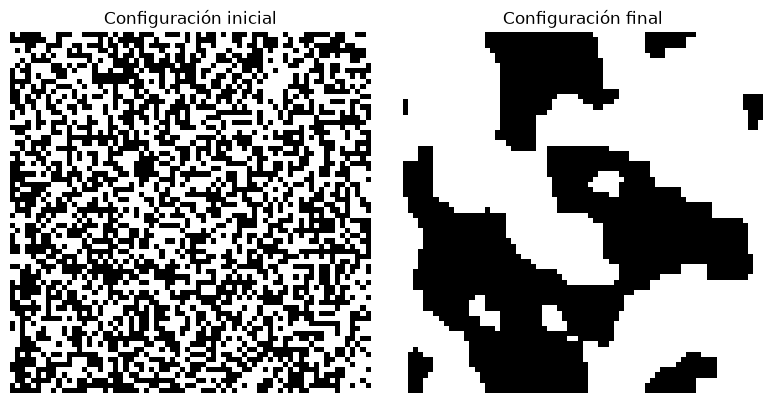

In [238]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))  


axes[0].imshow(p0, cmap='gray')
axes[0].set_title('Configuración inicial')
axes[0].axis('off')  

axes[1].imshow(p0_final, cmap='gray')
axes[1].set_title('Configuración final')
axes[1].axis('off')
plt.savefig("Configuraciones.jpeg")

plt.tight_layout()
plt.show()

In [224]:
def punto_estable(energia, ventana = 4000,tolerancia = 0.01 ):

    for i in range(0, len(energia) - 2*ventana, ventana):
    
        media1 = np.mean(energia[i:i+ventana])
        media2 = np.mean(energia[i+ventana:i+2*ventana])
    
        cambio_relativo = abs((media2 - media1) / media1)
    
        if cambio_relativo < tolerancia:
            return i + ventana

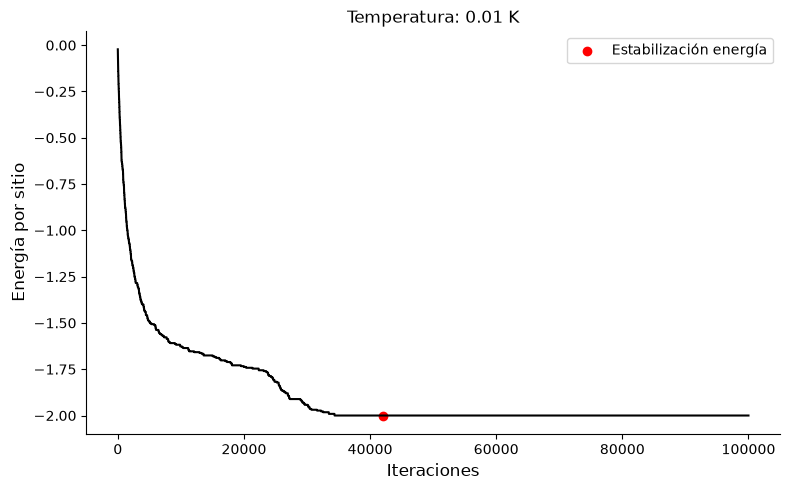

In [226]:
tiempo_algoritmo = np.arange(0, iteraciones, 1)

indice_estable = punto_estable(energia, ventana=7000)

plt.figure(figsize=(8, 5))

plt.plot(tiempo_algoritmo,energia, linewidth=1.5, c="k")
plt.scatter(tiempo_algoritmo[indice_estable], (energia)[indice_estable], c="r", label="Estabilización energía")

plt.xlabel("Iteraciones", fontsize=12)
plt.ylabel("Energía por sitio", fontsize=12)
plt.title("Temperatura: 0.01 K")

plt.tick_params(axis="both", labelsize=10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend()

plt.savefig("Temperatura: 0.01.jpeg")
plt.tight_layout()
plt.show()

In [251]:
iteraciones = 1000000
N = 50

p0 = init(N)
temperaturas = np.concatenate([np.random.choice(np.arange(0.01, critic_temperature, 0.1), size=3), np.random.choice(np.arange(critic_temperature, 8, 0.1), size=3)])
energias = []
p0_finales = []
magnetizaciones = []

for T in temperaturas:
    
    p0_final, energia, magnetizacion = metropolis_total(p0, iteraciones= iteraciones, beta=1/T, J= J, N=N, h = 0)
    energias.append(energia)
    p0_finales.append(p0_final)
    magnetizaciones.append(magnetizacion)
    

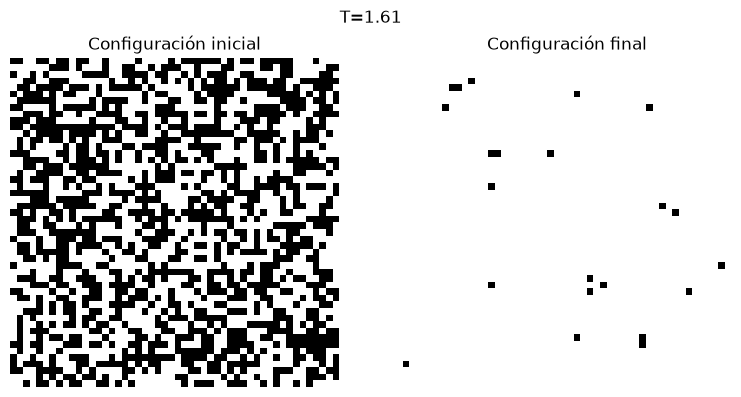

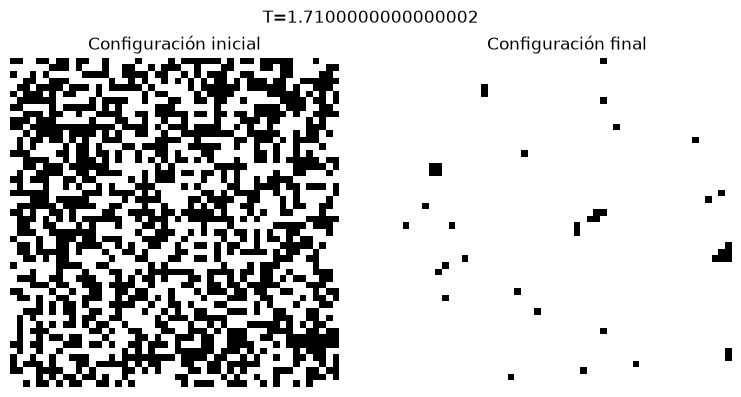

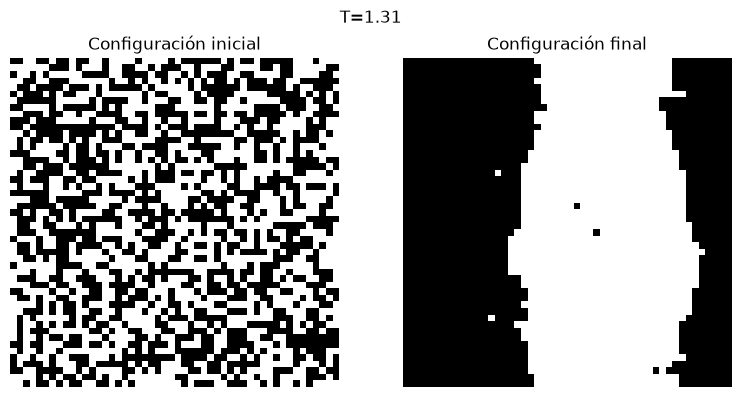

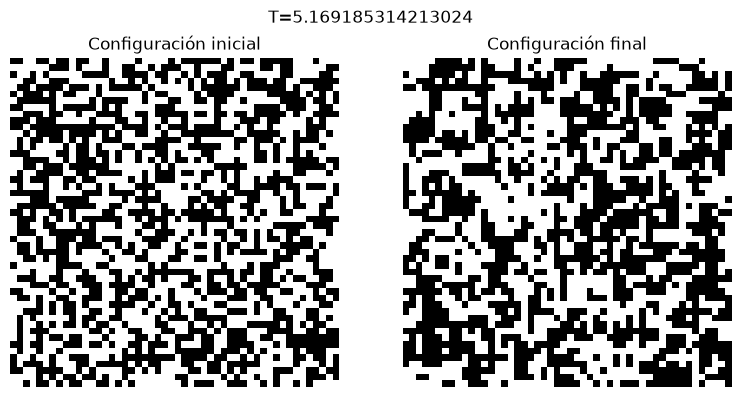

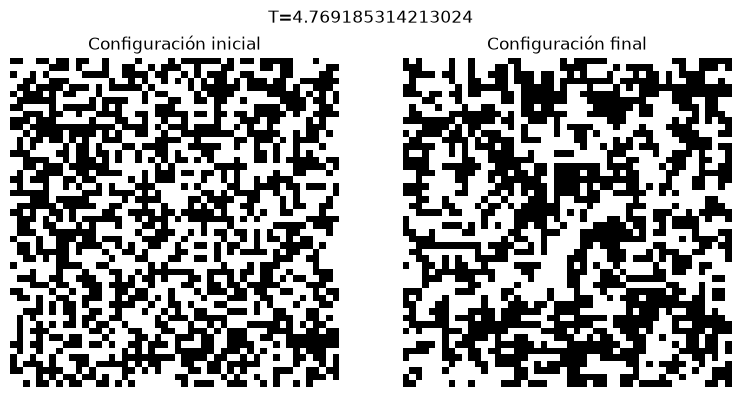

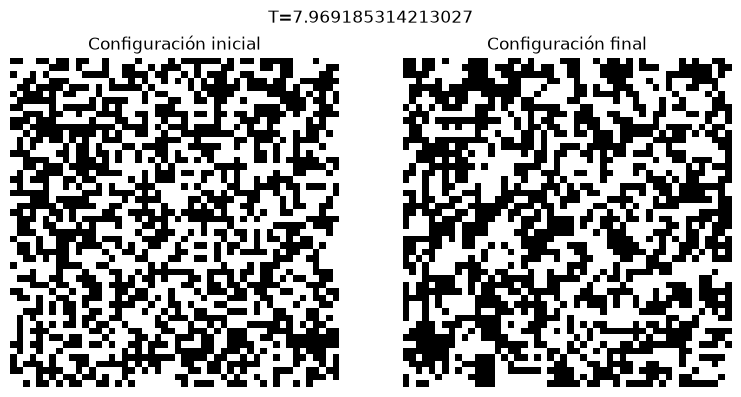

In [252]:
for T, p0_final in zip(temperaturas, p0_finales):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))  
    
    
    axes[0].imshow(p0, cmap='gray')
    axes[0].set_title('Configuración inicial')
    axes[0].axis('off')  
    
    axes[1].imshow(p0_final, cmap='gray')
    axes[1].set_title('Configuración final')
    axes[1].axis('off')

    
    fig.suptitle(f"T={T}")
    
    plt.tight_layout()
    plt.show()

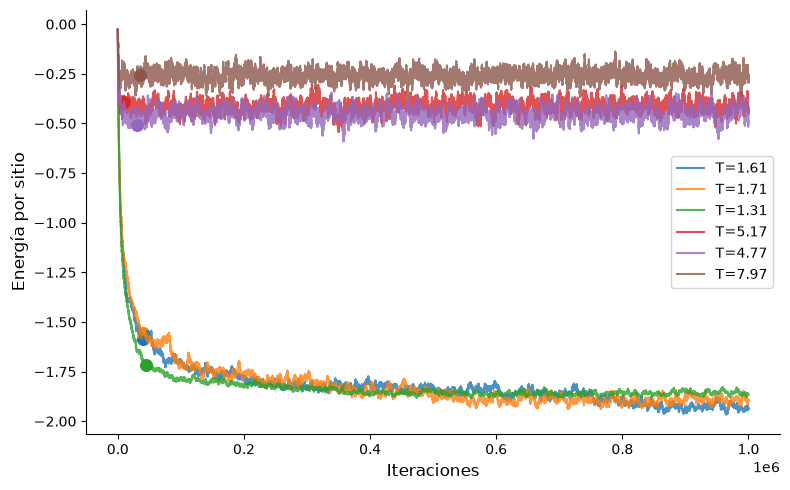

In [255]:
tiempo_algoritmo = np.arange(0, iteraciones, 1)

plt.figure(figsize=(8, 5))

resultados = {}

for T, energia, magnetizacion in zip(temperaturas, energias, magnetizaciones):
    
    indice_estable = punto_estable(energia, ventana=5000)
    
    resultados[T] = {"Energía promedio": np.mean(energia[indice_estable:]), "Magnetización promedio": np.mean(magnetizacion[indice_estable:])}
    
    line, = plt.plot(tiempo_algoritmo,energia, linewidth=1.5, label=f"T={T:.2f}", alpha=0.8)
    color = line.get_color()
    plt.scatter(tiempo_algoritmo[indice_estable], (energia)[indice_estable], color=color, s=70)
    
plt.xlabel("Iteraciones", fontsize=12)
plt.ylabel("Energía por sitio", fontsize=12)

plt.tick_params(axis="both", labelsize=10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.legend()
plt.tight_layout()
plt.savefig("Energia_dif_T.jpeg")
plt.show()

In [254]:
pd.DataFrame(resultados)

,1.610000,1.710000,1.310000,5.169185,4.769185,7.969185
Energía promedio,-1.836767,-1.836975,-1.841891,-0.414010,-0.452736,-0.257963
Magnetización promedio,0.701470,0.839264,-0.071598,0.002216,-0.002344,-0.004130


In [256]:
temperaturas = np.arange(0.1, 7, 0.1)
iteraciones = 1000000
N = 50
p0 = init(N)
energias_promedio = []
magnetizaciones_promedio = []

for T in temperaturas:
    
    _, energia, magnetizacion = metropolis_total(p0, iteraciones= iteraciones, beta=1/T, J= J, N=N, h = 0)

    indice_estable = punto_estable(energia, ventana=6000)
    
    energias_promedio.append(np.mean(energia[indice_estable:]))
    magnetizaciones_promedio.append(np.mean(magnetizacion[indice_estable:]))
    

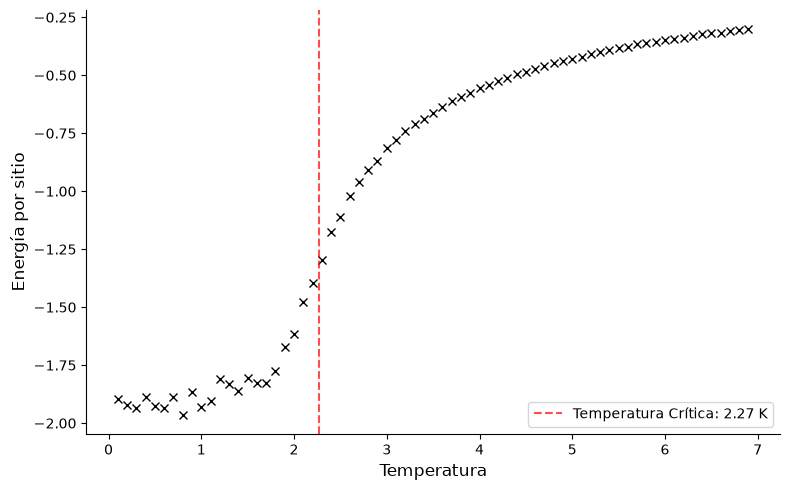

In [262]:
plt.figure(figsize=(8, 5))

plt.plot(temperaturas, energias_promedio, "x", c="k")
plt.tick_params(axis="both", labelsize=10)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.axvline(critic_temperature, ls="--", c="r", alpha=0.7, label=f"Temperatura Crítica: {critic_temperature:.2f} K")

plt.xlabel("Temperatura", fontsize=12)
plt.ylabel("Energía por sitio", fontsize=12)
plt.savefig("Energia.jpeg")
plt.legend()

plt.tight_layout()


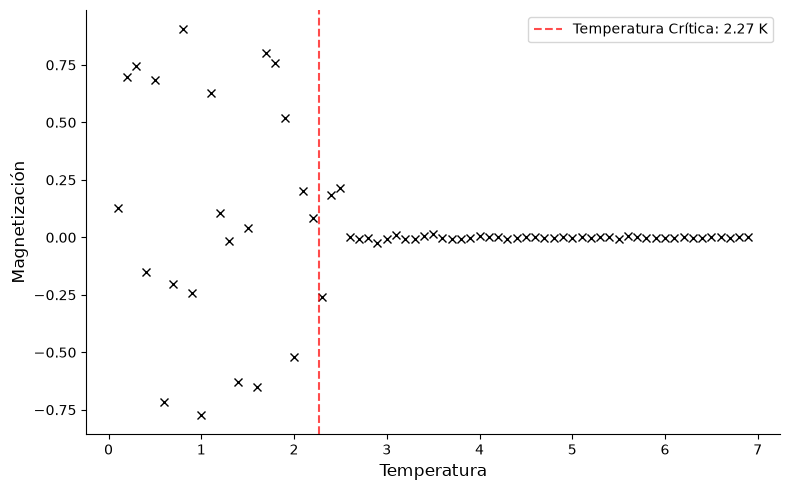

In [264]:
plt.figure(figsize=(8, 5))

plt.plot(temperaturas, magnetizaciones_promedio, "x", c="k")
plt.tick_params(axis="both", labelsize=10)
plt.axvline(critic_temperature, ls="--", c="r", alpha=0.7, label=f"Temperatura Crítica: {critic_temperature:.2f} K")


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("Temperatura", fontsize=12)
plt.ylabel("Magnetización", fontsize=12)
plt.legend()


plt.tight_layout()
plt.savefig("Magnetización")
